In [1]:
!pip install pillow

# Part 2 - Computer Vision Problem Formulation and CNN Prototype

In [2]:
# Importing required libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Problem Identification

The given dataset represents an image classification problem. 
The objective is to classify product images into different categories such as normal, scratch, dent, and stain.

Image classification is appropriate for this dataset because each image belongs to one specific category, and the CNN model learns visual patterns from the images to predict the correct class.

## Dataset Exploration

In [3]:
# Defining dataset paths

dataset_path = "dataset/images"

classes = ['normal', 'scratch', 'dent', 'stain']

### Number of Images per Class

In [4]:
# Counting images in each class

image_counts = {}

for category in classes:
    folder_path = os.path.join(dataset_path, category)
    image_counts[category] = len(os.listdir(folder_path))

image_counts

{'normal': 120, 'scratch': 120, 'dent': 120, 'stain': 120}

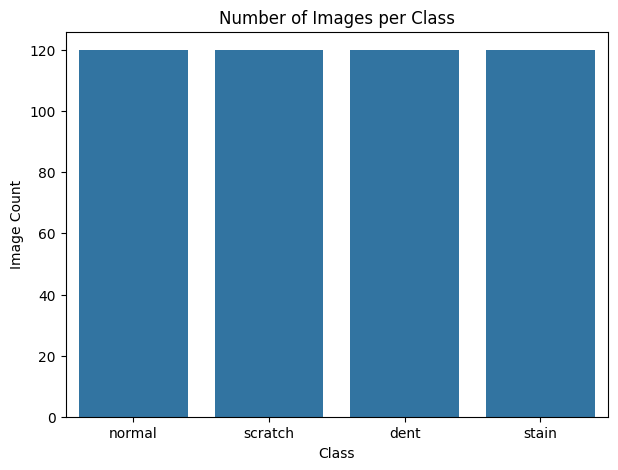

In [5]:
# Visualizing class distribution

plt.figure(figsize=(7,5))

sns.barplot(
    x=list(image_counts.keys()),
    y=list(image_counts.values())
)

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Image Count")

plt.show()

### Observation

The dataset contains four image categories:
- normal
- scratch
- dent
- stain

The class distribution graph helps in understanding whether the dataset is balanced across categories. 
A balanced dataset generally helps the CNN model learn all classes more effectively, while an imbalanced dataset may cause the model to become biased toward certain classes.

### Sample Images from Each Class

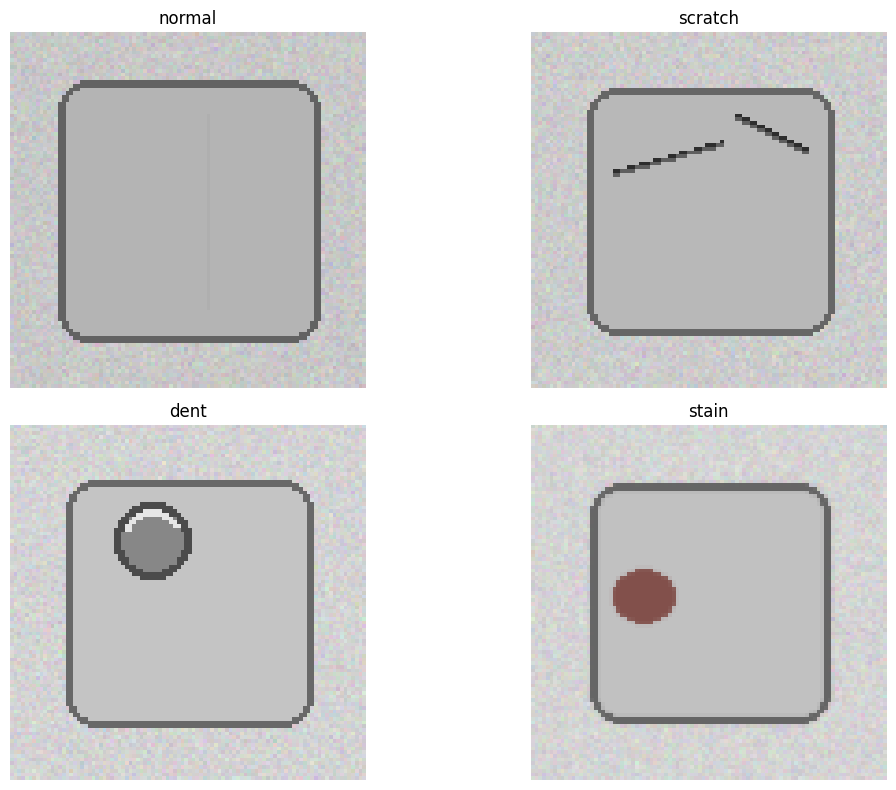

In [6]:
# Displaying sample images from each class

plt.figure(figsize=(12,8))

for i, category in enumerate(classes):

    folder_path = os.path.join(dataset_path, category)

    image_name = os.listdir(folder_path)[0]

    image_path = os.path.join(folder_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)

    plt.imshow(image)

    plt.title(category)

    plt.axis('off')

plt.tight_layout()

plt.show()

### Image Dimension Analysis

In [7]:
# Checking dimensions of sample images

for category in classes:

    folder_path = os.path.join(dataset_path, category)

    image_name = os.listdir(folder_path)[0]

    image_path = os.path.join(folder_path, image_name)

    image = Image.open(image_path)

    print(f"{category} image size:", image.size)

normal image size: (96, 96)
scratch image size: (96, 96)
dent image size: (96, 96)
stain image size: (96, 96)


### Observation

The images may contain different dimensions depending on how they were collected or generated. 
Before training the CNN model, all images will be resized to a fixed dimension so that the neural network can process them consistently.

Image resizing is an important preprocessing step in computer vision tasks because CNN models require uniform input dimensions.

## Image Preprocessing

### Preprocessing Approach

The images are preprocessed before training the CNN model.

The preprocessing steps include:
- Resizing all images to a fixed size
- Normalizing pixel values
- Splitting images into training and validation datasets
- Applying data augmentation techniques to improve generalization

Data augmentation helps the model learn more robust image patterns by creating slightly modified versions of training images.

In [8]:
# Creating image generators

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


## CNN Model Creation

### CNN Architecture

A Convolutional Neural Network (CNN) is used for this image classification task because CNNs are designed specifically for image data.

The model contains:
- Convolution layers for feature extraction
- ReLU activation functions for learning non-linear patterns
- Pooling layers for dimensionality reduction
- Flatten layer for converting feature maps into vectors
- Dense layers for final classification

The output layer uses softmax activation because this is a multi-class classification problem.

In [10]:
# Building the CNN model

cnn_model = Sequential()

# First convolution block
cnn_model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(128, 128, 3)
))

cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution block
cnn_model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
cnn_model.add(Flatten())

# Dense layer
cnn_model.add(Dense(128, activation='relu'))

# Dropout layer
cnn_model.add(Dropout(0.3))

# Output layer
cnn_model.add(Dense(4, activation='softmax'))

c:\Users\Arif Ahmed Vastari\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compiling the CNN model

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
# Displaying model summary

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## CNN Model Training

### Training Process

The CNN model learns image patterns during training by extracting important visual features such as edges, textures, and shapes from the images.

During each epoch:
- The model performs forward propagation
- Prediction error is calculated using the loss function
- Backpropagation updates the weights
- Accuracy and loss values are monitored

Validation accuracy helps in understanding how well the model generalizes to unseen images.

In [13]:
# Training the CNN model

cnn_history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 359ms/step - accuracy: 0.2370 - loss: 2.5295 - val_accuracy: 0.2500 - val_loss: 1.3986
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step - accuracy: 0.2917 - loss: 1.3879 - val_accuracy: 0.5104 - val_loss: 1.3768
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 298ms/step - accuracy: 0.4010 - loss: 1.3709 - val_accuracy: 0.5104 - val_loss: 1.3505
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step - accuracy: 0.5000 - loss: 1.3165 - val_accuracy: 0.6667 - val_loss: 1.2700
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 302ms/step - accuracy: 0.5365 - loss: 1.2340 - val_accuracy: 0.4792 - val_loss: 1.1462
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - accuracy: 0.5859 - loss: 1.0899 - val_accuracy: 0.4479 - val_loss: 1.0304
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.5990 - loss: 1.0145 - val_accuracy: 0.6146 - val_loss: 0.9010
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.6536 - loss: 0.8895 - val_accuracy: 0.

### Training Observation

During training, the CNN model gradually improves its ability to recognize image patterns associated with each defect category.

The training accuracy and validation accuracy provide insight into the model’s learning behavior. 
If validation accuracy improves consistently along with training accuracy, it indicates stable learning and better generalization performance.

## CNN Model Evaluation

In [14]:
# Evaluating the CNN model

test_loss, test_accuracy = cnn_model.evaluate(validation_generator)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.7396 - loss: 0.6702
Validation Loss: 0.6702296733856201
Validation Accuracy: 0.7395833134651184


In [15]:
# Generating predictions

predictions = cnn_model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


### Confusion Matrix

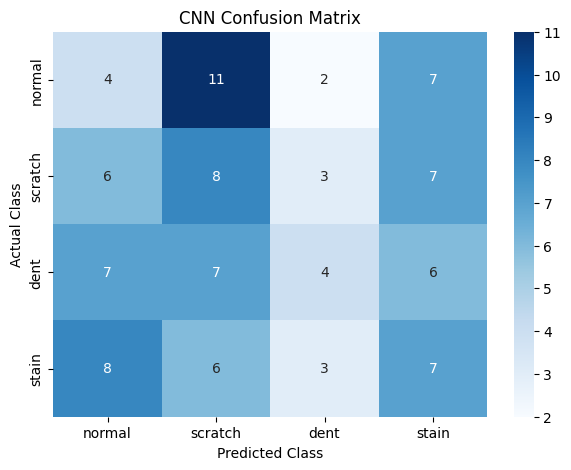

In [16]:
# Creating confusion matrix

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

# Saving confusion matrix
plt.savefig("results/confusion_matrix.png")

plt.show()

In [17]:
# Classification report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=classes
))

              precision    recall  f1-score   support

      normal       0.16      0.17      0.16        24
     scratch       0.25      0.33      0.29        24
        dent       0.33      0.17      0.22        24
       stain       0.26      0.29      0.27        24

    accuracy                           0.24        96
   macro avg       0.25      0.24      0.24        96
weighted avg       0.25      0.24      0.24        96



### Accuracy and Loss Curves

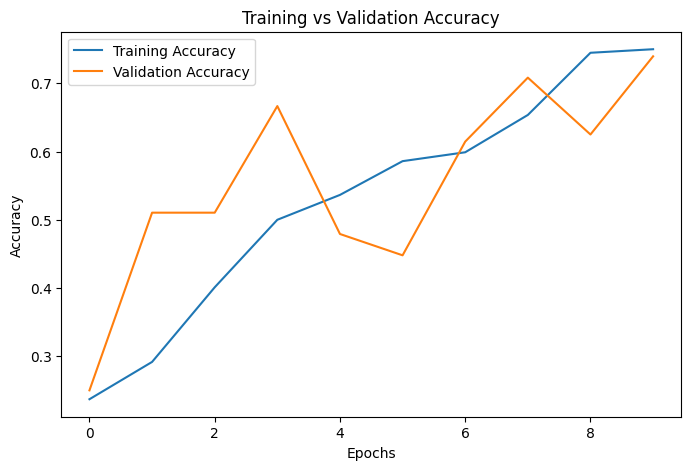

In [18]:
# Plotting accuracy curves

plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

# Saving accuracy curve
plt.savefig("results/accuracy_loss_curves.png")

plt.show()

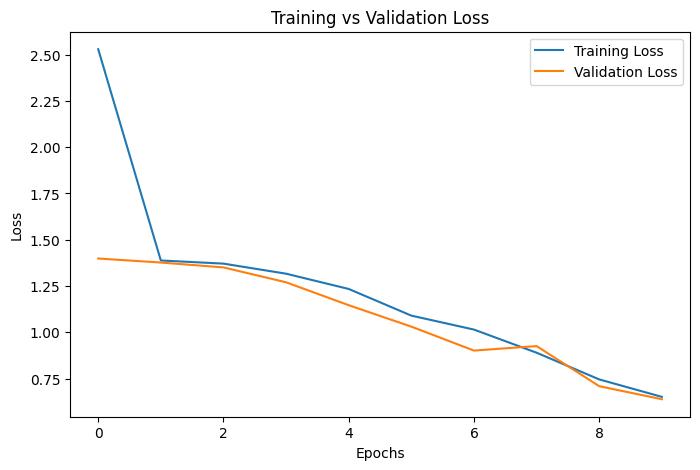

In [19]:
# Plotting loss curves

plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.show()

### Model Evaluation Interpretation

The CNN model achieved reasonable classification performance on the validation dataset. 
The confusion matrix provides a detailed understanding of how accurately the model classified each image category.

Some classes may be predicted more accurately than others depending on:
- image quality
- class imbalance
- visual similarity between categories

The training and validation accuracy curves help in analyzing model learning behavior. 
A small gap between training and validation accuracy generally indicates stable generalization, while a large gap may suggest overfitting.

The loss curves also help in understanding whether the model is effectively minimizing prediction error during training.

## Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


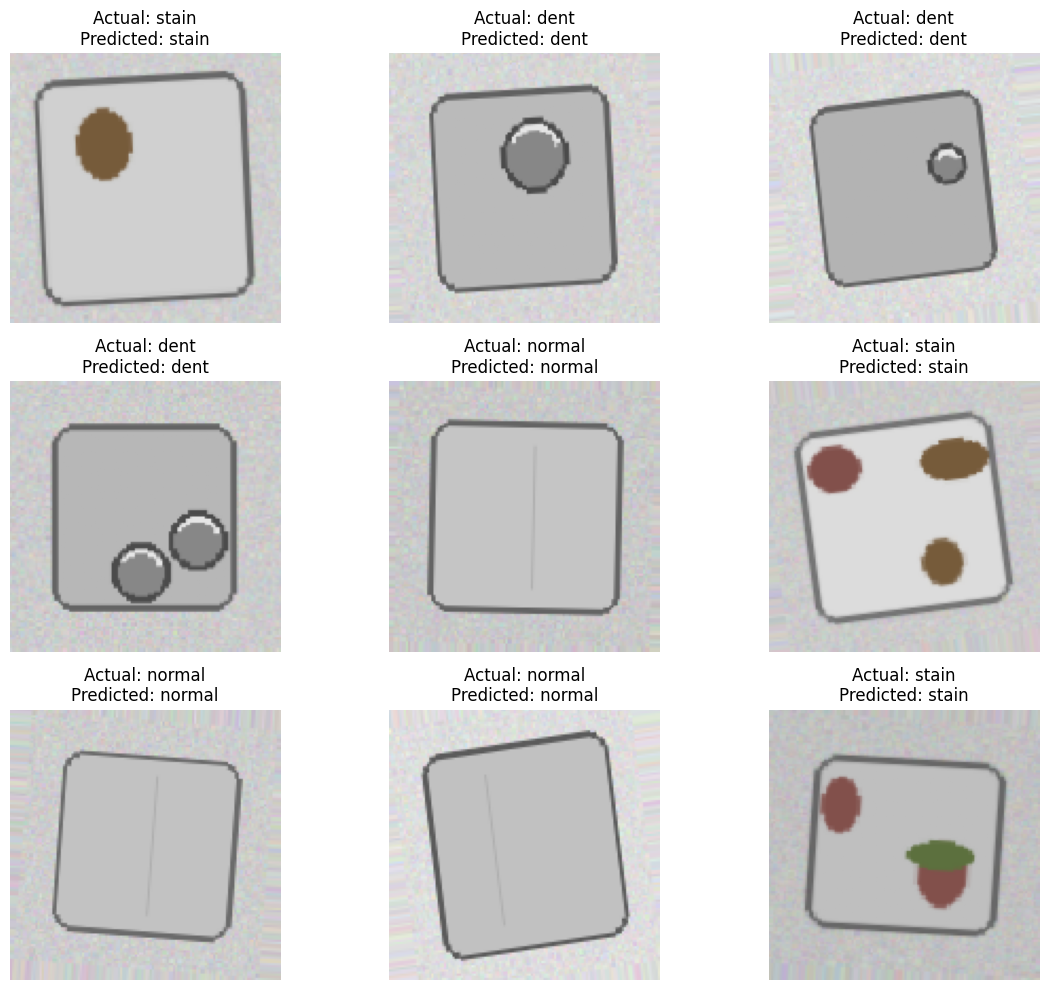

In [20]:
# Displaying sample predictions

class_labels = list(validation_generator.class_indices.keys())

images, labels = next(validation_generator)

predictions = cnn_model.predict(images)

predicted_labels = np.argmax(predictions, axis=1)

true_labels = np.argmax(labels, axis=1)

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.title(
        f"Actual: {class_labels[true_labels[i]]}\nPredicted: {class_labels[predicted_labels[i]]}"
    )

    plt.axis('off')

plt.tight_layout()

# Saving sample predictions
plt.savefig("sample_predictions/prediction_outputs.png")

plt.show()

## CNN Concept Explanation

### What is Convolution?

Convolution is the process where small filters move across the image to detect important visual patterns such as edges, textures, shapes, and object features.

Different filters learn different patterns from the images during training. 
These learned patterns help the CNN model identify differences between categories such as scratches, dents, stains, and normal surfaces.

---

### Why is Pooling Used?

Pooling is used to reduce the size of feature maps generated by convolution layers.

This helps:
- reduce computational complexity
- reduce memory usage
- focus on important visual information
- improve generalization

Max pooling is commonly used because it preserves the strongest and most important features from the image.

---

### Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) is widely used because it introduces non-linearity into the model and helps the neural network learn complex image patterns.

ReLU is computationally efficient and helps reduce issues such as vanishing gradients during training. 
It also helps CNN models train faster compared to some traditional activation functions.

---

### Why are CNNs Better than Regular Feed-Forward Networks for Images?

CNNs are specifically designed for image data because they can automatically learn spatial and visual patterns from images.

Regular feed-forward neural networks treat every pixel independently, which becomes inefficient for large images. 
CNNs preserve spatial relationships between pixels and extract meaningful visual features using convolution operations.

This makes CNNs more effective and scalable for computer vision tasks such as image classification, object detection, and defect identification.

## Business Use Case Mapping

### Manufacturing Industry Use Case

This type of computer vision solution can be applied in the manufacturing industry for automated defect detection.

In traditional manufacturing environments, product inspection is often performed manually by quality control teams. 
Manual inspection can be time-consuming, inconsistent, and prone to human error, especially when dealing with large production volumes.

A CNN-based image classification system can automatically identify product defects such as:
- scratches
- dents
- stains
- surface abnormalities

By analyzing product images in real time, the system can help:
- improve quality control
- reduce defective product shipments
- minimize operational costs
- increase inspection speed
- maintain consistent quality standards

Such AI-based inspection systems are widely used in industries such as automotive manufacturing, electronics production, and packaging.